# Clustering neurons finds structure, but not brain regions

The three tests of the head-direction figure
(`duszkiewicz_analyses/notebooks/hd_clustering.ipynb`), applied to Posani, Wang et al. (2026)
with **brain regions** in the role that individual animals played there:

1. **a** -- do the neurons form clusters at all, against a single continuous cloud?
2. **b** -- does any such structure belong to individual regions, against size-matched
   pseudo-regions?
3. **c** -- do whole populations separate regions, once compared with a shape metric?

Panel a is Posani et al.'s own analysis. Panels b and c are the question this paper adds: if
neuron-level clustering finds cell types rather than regions, then a region's own neurons
should be no more clusterable than an arbitrary set of the same size (b), while the region's
*population geometry* should still tell it apart from other regions (c).

Everything is reused: the data through `code/data.py`, the clustering pipeline unmodified from
`clustering-analysis/`, and the panel style and constants from the head-direction figure.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sts
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score
from netrep.metrics import LinearMetric
import tqdm

sys.path.insert(0, "code")
sys.path.insert(0, "clustering-analysis/single_area")
import data                                                             # noqa: E402
from utils.clustering_analysis import cluster_analysis_condition_space  # noqa: E402
from utils.clustering_algo import clustering                            # noqa: E402
from utils.dr_algo import dr                                            # noqa: E402

OUT = Path.cwd() / "results/region_clustering"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

# the head-direction figure's style and constants, unchanged
PANEL, NULLC, DATAC = 2.1, "0.75", "darkred"
N_NULL, R_PSEUDO, N_DRAW, N_PCS = 100, 20, 100, 20

## The data

The selective neurons of the 22 regions that pass the paper's own criteria, each described by
its full time-varying encoding profile: 8 task variables x 100 time bins.

In [2]:
d = data.Dataset()
sel = d.keep & np.isin(d.acronym, d.regions)
X = d.features("temporal")[sel].astype(float)
region = d.acronym[sel]
regions = np.array(d.regions)

print(f"{len(X)} neurons x {X.shape[1]} features, {len(regions)} regions")
print(f"  neurons per region: min {d.counts.min()}, median {int(np.median(d.counts))}, "
      f"max {d.counts.max()}")

4092 neurons x 800 features, 22 regions
  neurons per region: min 67, median 120, max 754


## a. Do the neurons form clusters at all?

Posani et al.'s pipeline, unmodified: standardise each neuron across conditions, PCA to 90% of
the variance, sweep k and keep the best silhouette. Silhouette cannot score k = 1, so the
one-cluster hypothesis is simulated -- `N_NULL` draws from a single Gaussian matched to the
real cloud's mean and covariance, each swept identically.

In [3]:
f = OUT / "a_condition_space.npz"
if f.exists():
    dd = np.load(f, allow_pickle=True)
    a_obs, a_null, a_z, a_lab = (float(dd["obs"]), dd["null"], float(dd["z"]), dd["labels"])
else:
    r = cluster_analysis_condition_space(
        X,
        {"min_N": 50, "algo": "kmeans", "n_init": 50, "n_clus_lim": [3, 21],
         "dis_metric": "euclidean", "save_id": "posani_regions"},
        {"remove_sus_clus": False, "sessions_orig": np.zeros(len(X), int),
         "sus_clus_thres": 0.9},
        {"N_null": N_NULL, "null_dist": "Gaussian"},
        dict(plot=False, folder=str(OUT), save_id="posani_regions"))
    a_obs, a_null = float(r["sscore_mean"]), np.asarray(r["sscore_nulls"])
    a_z, a_lab = float(r["sscore_z"]), np.asarray(r["clus_labels"])
    np.savez(f, obs=a_obs, null=a_null, z=a_z, labels=a_lab)

a_k = len(np.unique(a_lab))
print(f"a: silhouette {a_obs:.4f}   null {a_null.mean():.4f} +/- {a_null.std():.4f}"
      f"   z = {a_z:+.2f}   (k = {a_k})")

a: silhouette 0.0849   null 0.0790 +/- 0.0032   z = +1.88   (k = 10)


## b. Does that structure belong to individual regions?

For each region, the best silhouette of *its own* neurons, against `R_PSEUDO` size-matched
pseudo-regions drawn at random from the whole pool. A positive z would mean a region's neurons
cluster better than an arbitrary set of the same size -- that neuron-level clustering tracks
regions.

In [4]:
Xs = (X - X.mean(1, keepdims=True)) / X.std(1, keepdims=True)
Z = dr(Xs, dict(method="pca", exp_var=0.9))
print(f"clustering space: {Z.shape[1]} dimensions")


def best_sil(Zsub):
    kmax = max(2, min(10, len(Zsub) // 10))
    return clustering(Zsub, "kmeans", n_clus_lim=[2, kmax + 1],
                      dis_metric="euclidean", n_init=50)["sscores_mean"]


f = OUT / "b_pseudo_regions.npy"
if f.exists():
    b_res = np.load(f)
else:
    rng = np.random.default_rng(0)
    rows = []
    for r_ in tqdm.tqdm(regions, desc="regions"):
        m = region == r_
        real = best_sil(Z[m])
        null = np.array([best_sil(Z[rng.choice(len(Z), int(m.sum()), replace=False)])
                         for _ in range(R_PSEUDO)])
        rows.append((real, null.mean(), (real - null.mean()) / (null.std() + 1e-12)))
    b_res = np.array(rows)
    np.save(f, b_res)

b_z = b_res[:, 2]
b_p = sts.wilcoxon(b_res[:, 0], b_res[:, 1]).pvalue
print(f"b: mean z {b_z.mean():+.3f} (sd {b_z.std(ddof=1):.2f})   Wilcoxon p {b_p:.3f}"
      f"   {(b_z > 2).sum()} above +2, {(b_z < -2).sum()} below -2")

clustering space: 25 dimensions
b: mean z +5.237 (sd 4.30)   Wilcoxon p 0.000   17 above +2, 0 below -2


## c. Do whole populations separate regions?

The shape-metric version. Each region becomes one point cloud and regions are compared with
the Procrustes distance; the null reassigns neurons to regions at random, preserving how many
neurons each region has.

**Every region is subsampled to the same `N_SUB` neurons**, and the matrix averaged over
`N_REPEATS` draws, exactly as `shape.distance_matrix` does for the main notebook. That is not
a detail. Without it the distances inherit each region's sample size -- a region with 754
neurons has a well-estimated geometry, one with 67 a noisy one that sits far from everything --
and k-means then partitions the 22 regions into *large* versus *small* rather than into
anything anatomical. Run that way, both the real data and the shuffles split 5 big regions
against 17 small ones and the shuffles score *higher*, because there sample size is the only
signal left. Equalising the samples removes the artefact.

Two statistics are reported. `best silhouette` is the head-direction figure's: how clumped the
22 regions are. `mean distance` is separability: how far apart they are at all. They answer
different questions, and a continuum can be highly separable while clustering badly.

In [5]:
from procrustes import preprocess, pairwise      # the main notebook's own routines

N_SUB, N_PCS_D, N_REPEATS = 50, 25, 20          # as in shape.distance_matrix


def region_distances(labels, n_sub=N_SUB, n_pcs=N_PCS_D, n_repeats=N_REPEATS, seed=0):
    """Procrustes distances between the groups of `labels`, at equal sample size."""
    rng = np.random.default_rng(seed)
    u = np.unique(labels)
    idx = {r_: np.where(labels == r_)[0] for r_ in u}
    D = np.zeros((len(u), len(u)))
    for _ in range(n_repeats):
        Xs = [preprocess(X[rng.choice(idx[r_], n_sub, replace=False)].T, n_pcs) for r_ in u]
        D += pairwise(Xs)
    return D / n_repeats


def cluster_strength(D, seed=0):
    """Posani's statistic on the region-by-region matrix: sweep k, keep the best."""
    emb = MDS(n_components=5, dissimilarity="precomputed", random_state=seed,
              normalized_stress=False, n_init=4).fit_transform(D)
    return max(silhouette_score(emb, KMeans(k, n_init=50, init="random",
                                            random_state=42).fit_predict(emb))
               for k in range(2, 8))


iu = np.triu_indices(len(regions), 1)

f = OUT / "c_region_clustering.npz"
if f.exists():
    dd = np.load(f)
    c_obs, c_null = float(dd["obs"]), dd["null"]
    s_obs, s_null, D_reg = float(dd["sep_obs"]), dd["sep_null"], dd["D"]
else:
    D_reg = region_distances(region)
    c_obs, s_obs = cluster_strength(D_reg), D_reg[iu].mean()
    rng = np.random.default_rng(0)
    c_null, s_null = [], []
    for _ in tqdm.trange(N_DRAW, desc="shuffles"):
        Dn = region_distances(rng.permutation(region))
        c_null.append(cluster_strength(Dn))
        s_null.append(Dn[iu].mean())
    c_null, s_null = np.array(c_null), np.array(s_null)
    np.savez(f, obs=c_obs, null=c_null, sep_obs=s_obs, sep_null=s_null, D=D_reg)

c_z = (c_obs - c_null.mean()) / c_null.std()
c_p = (np.sum(c_null >= c_obs) + 1) / (len(c_null) + 1)
s_z = (s_obs - s_null.mean()) / s_null.std()
s_p = (np.sum(s_null >= s_obs) + 1) / (len(s_null) + 1)
print(f"c: best silhouette {c_obs:.4f}   shuffled regions {c_null.mean():.4f} "
      f"+/- {c_null.std():.4f}   z = {c_z:+.2f}, p = {c_p:.3f}")
print(f"   mean distance  {s_obs:.4f}   shuffled regions {s_null.mean():.4f} "
      f"+/- {s_null.std():.4f}   z = {s_z:+.2f}, p = {s_p:.3f}")

# the artefact this guards against, for the record
sizes = np.array([int((region == r_).sum()) for r_ in regions])
emb = MDS(n_components=5, dissimilarity="precomputed", random_state=0,
          normalized_stress=False, n_init=4).fit_transform(D_reg)
lab2 = KMeans(2, n_init=50, init="random", random_state=42).fit_predict(emb)
print(f"   k=2 split at equal sample size: sizes {np.bincount(lab2).tolist()}, "
      f"median neurons/region per cluster "
      f"{[int(np.median(sizes[lab2 == c_])) for c_ in (0, 1)]}")

/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


shuffles:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
shuffles:   1%|          | 1/100 [00:00<01:14,  1.33it/s]

/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
shuffles:   2%|▏         | 2/100 [00:01<01:14,  1.32it/s]

/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
shuffles:   3%|▎         | 3/100 [00:02<01:13,  1.32it/s]

...

/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
shuffles:  99%|█████████▉| 99/100 [01:08<00:00,  1.55it/s]

/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
shuffles: 100%|██████████| 100/100 [01:09<00:00,  1.55it/s]

shuffles: 100%|██████████| 100/100 [01:09<00:00,  1.45it/s]


/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


c: best silhouette 0.1662   shuffled regions 0.1190 +/- 0.0043   z = +11.03, p = 0.010
   mean distance  0.7111   shuffled regions 0.5455 +/- 0.0026   z = +63.84, p = 0.010
   k=2 split at equal sample size: sizes [14, 8], median neurons/region per cluster [111, 132]


## The figure

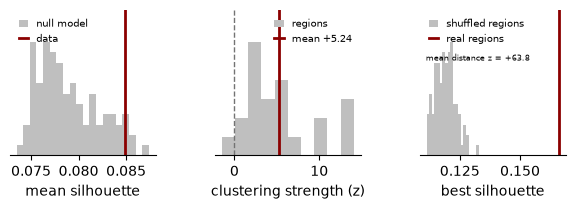

a  silhouette 0.0849 vs 0.0790 +/- 0.0032, z = +1.88, k = 10
b  mean z +5.24, Wilcoxon p = 0.000
c  best silhouette 0.1662 vs 0.1190 +/- 0.0043, z = +11.03, p = 0.010
c  mean distance   0.7111 vs 0.5455 +/- 0.0026, z = +63.84, p = 0.010


In [6]:
def style(ax, xlabel, loc="upper left"):
    ax.set_xlabel(xlabel)
    ax.set_yticks([])
    lo, hi = ax.get_ylim()
    ax.set_ylim(lo, hi * 1.22)
    ax.legend(frameon=False, fontsize=7, loc=loc, handlelength=1.0)
    ax.set_box_aspect(1)
    sns.despine(ax=ax, left=True)


fig, axes = plt.subplots(1, 3, figsize=(3 * PANEL, PANEL))

ax = axes[0]
ax.hist(a_null, bins=20, color=NULLC, label="null model")
ax.axvline(a_obs, color=DATAC, lw=2, label="data")
style(ax, "mean silhouette")

ax = axes[1]
ax.hist(b_z, bins=10, color=NULLC, label="regions")
ax.axvline(0, color="0.45", lw=1, ls="--")
ax.axvline(b_z.mean(), color=DATAC, lw=2, label=f"mean {b_z.mean():+.2f}")
style(ax, "clustering strength (z)", "upper right")

ax = axes[2]
ax.hist(c_null, bins=20, color=NULLC, label="shuffled regions")
ax.axvline(c_obs, color=DATAC, lw=2, label="real regions")
style(ax, "best silhouette")
ax.annotate(f"mean distance z = {s_z:+.1f}", (.04, .70), xycoords="axes fraction",
            fontsize=6, va="top")

fig.tight_layout()
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_clustering_panels.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

print(f"a  silhouette {a_obs:.4f} vs {a_null.mean():.4f} +/- {a_null.std():.4f}, "
      f"z = {a_z:+.2f}, k = {a_k}")
print(f"b  mean z {b_z.mean():+.2f}, Wilcoxon p = {b_p:.3f}")
print(f"c  best silhouette {c_obs:.4f} vs {c_null.mean():.4f} +/- {c_null.std():.4f}, "
      f"z = {c_z:+.2f}, p = {c_p:.3f}")
print(f"c  mean distance   {s_obs:.4f} vs {s_null.mean():.4f} +/- {s_null.std():.4f}, "
      f"z = {s_z:+.2f}, p = {s_p:.3f}")